In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import kagglehub

path = kagglehub.dataset_download(
    "andrerathje/house-prices-advanced-regression-techniques"
)

print(path)

100%|██████████| 199k/199k [00:00<00:00, 16.7MB/s]

Extracting files...
/root/.cache/kagglehub/datasets/andrerathje/house-prices-advanced-regression-techniques/versions/1


In [ ]:
import os

print(os.listdir(path))

['data_description.txt', 'test.csv', 'sample_submission.csv', 'train.csv']


In [ ]:
file_path = os.path.join(path, "train.csv")
df = pd.read_csv(file_path)

In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
print(df.shape)

(1460, 81)


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

Handling Missing Values

In [ ]:
missing=df.isnull().sum()
missing=missing[missing>0]
missing.sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [ ]:
missing_percent=(df.isnull().sum()/len(df))*100
print(missing_percent)
missing_percent[missing_percent>0].sort_values(ascending=False)

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64


,0
PoolQC,99.520548
MiscFeature,96.301370
Alley,93.767123
Fence,80.753425
MasVnrType,59.726027
FireplaceQu,47.260274
LotFrontage,17.739726
GarageType,5.547945
GarageYrBlt,5.547945
GarageFinish,5.547945


In [ ]:
drop_cols=missing_percent[missing_percent>50].index
print(drop_cols)
df.drop(columns=drop_cols,inplace=True)

Index(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'], dtype='object')


In [ ]:
fill_cols=missing_percent[(missing_percent<=50) & (missing_percent>0)].index
print(fill_cols)

Index(['LotFrontage', 'MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
       'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual',
       'GarageCond'],
      dtype='object')


In [ ]:
num_fill_cols=df[fill_cols].select_dtypes(include=["float64","int64"]).columns
for i in num_fill_cols:
  df[i]=df[i].fillna(df[i].mean())

In [ ]:
cat_fill_cols=df[fill_cols].select_dtypes(include="object").columns
for i in cat_fill_cols:
  df[i]=df[i].fillna(df[i].mode()[0])

In [ ]:
print(df.isnull().sum())

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
                ..
MoSold           0
YrSold           0
SaleType         0
SaleCondition    0
SalePrice        0
Length: 76, dtype: int64


In [ ]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,...,0,0,0,0,0,12,2008,WD,Normal,250000


Drop Unwanted Column

In [ ]:
df.drop("Id",axis=1,inplace=True)

In [ ]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


Data Visualization

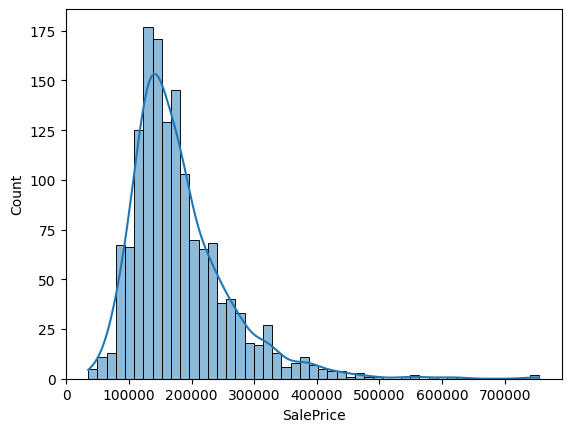

In [ ]:
sns.histplot(df["SalePrice"],kde=True)
plt.show()

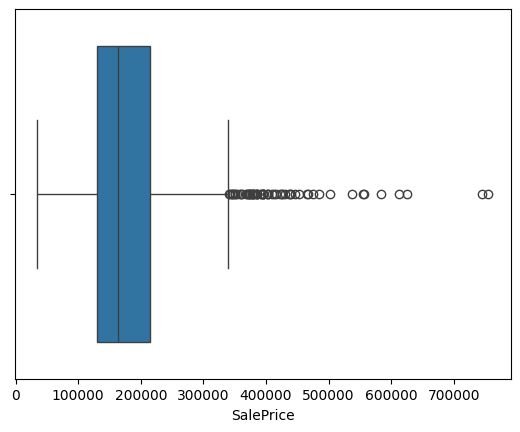

In [ ]:
sns.boxplot(x=df["SalePrice"])
plt.show()

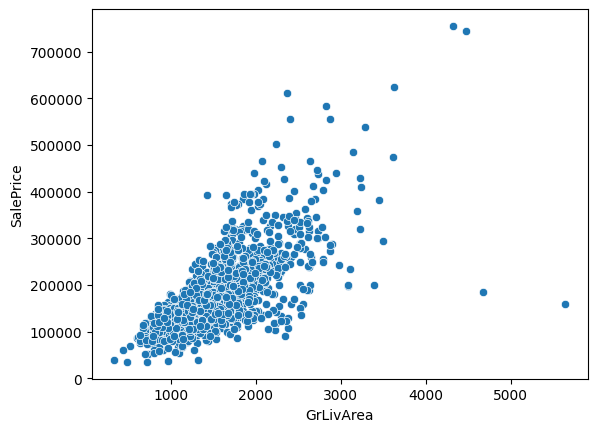

In [ ]:
sns.scatterplot(x=df["GrLivArea"],y=df["SalePrice"])
plt.show()

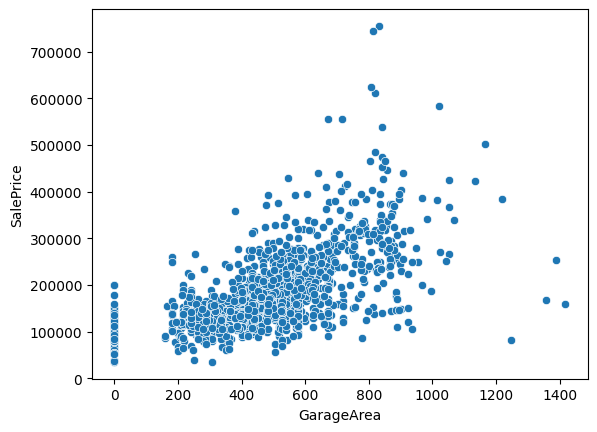

In [ ]:

sns.scatterplot(x=df["GarageArea"],y=df["SalePrice"])
plt.show()

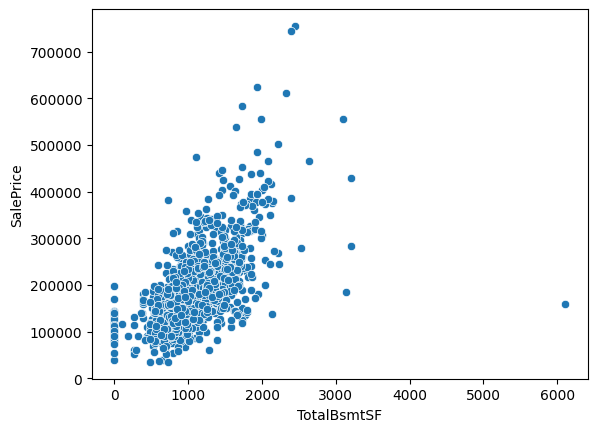

In [ ]:
sns.scatterplot(x=df["TotalBsmtSF"],y=df["SalePrice"])
plt.show()

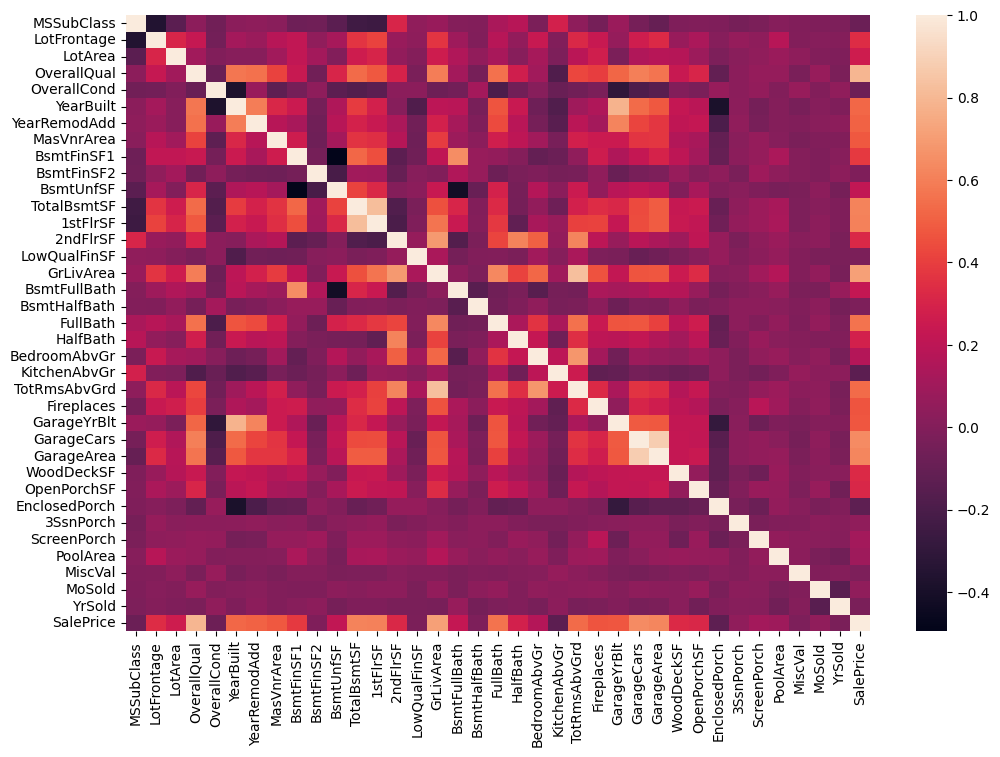

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True))
plt.show()

In [ ]:

corr = df.corr(numeric_only=True)

corr["SalePrice"].sort_values(ascending=False)

,SalePrice
SalePrice,1.000000
OverallQual,0.790982
GrLivArea,0.708624
GarageCars,0.640409
GarageArea,0.623431
TotalBsmtSF,0.613581
1stFlrSF,0.605852
FullBath,0.560664
TotRmsAbvGrd,0.533723
YearBuilt,0.522897


In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [ ]:
cat_cols=X_train.select_dtypes(include="object").columns
print(cat_cols)

Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual',
       'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
       'SaleType', 'SaleCondition'],
      dtype='object')


In [ ]:
from sklearn.preprocessing import OneHotEncoder
encoder=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=encoder.fit(X_train[cat_cols])

In [ ]:
X_train_encoded=encoder.transform(X_train[cat_cols])
X_test_encoded=encoder.transform(X_test[cat_cols])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [14, 29] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [ ]:
train_encoded_df=pd.DataFrame(
    X_train_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_train.index
)
test_encoded_df=pd.DataFrame(
    X_test_encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X_test.index
)

In [ ]:
num_cols=X_train.select_dtypes(exclude=object).columns
X_train_final=pd.concat([X_train[num_cols],train_encoded_df],axis=1)
X_test_final=pd.concat([X_test[num_cols],test_encoded_df],axis=1)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train_final),
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_test = pd.DataFrame(
    imputer.transform(X_test_final),
    columns=X_test_final.columns,
    index=X_test_final.index
)

Check the new data

In [ ]:
print(X_train.shape)
print(X_test.shape)

(1168, 259)
(292, 259)


In [ ]:
X_train.isnull().sum().sum()

np.int64(0)

In [ ]:
X_test.isnull().sum().sum()

np.int64(0)

In [ ]:
X_train.head()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,255.0,20.0,70.0,8400.0,5.0,6.0,1957.0,1957.0,0.0,922.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1066,1067.0,60.0,59.0,7837.0,6.0,7.0,1993.0,1994.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
638,639.0,30.0,67.0,8777.0,5.0,7.0,1910.0,1950.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
799,800.0,50.0,60.0,7200.0,5.0,7.0,1937.0,1950.0,252.0,569.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
380,381.0,50.0,50.0,5000.0,5.0,6.0,1924.0,1950.0,0.0,218.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [ ]:
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

In [ ]:
lin_model=LinearRegression()
ridge=Ridge()
lasso=Lasso()
knn=KNeighborsRegressor()
svm_model=SVR()

In [ ]:
lin_model.fit(X_train_scaled,y_train)
y_pred_lin=lin_model.predict(X_test_scaled)

ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)

svm_model.fit(X_train_scaled, y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.030e+11, tolerance: 6.967e+08
  model = cd_fast.enet_coordinate_descent(


In [ ]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [ ]:
def evaluate_model(name,y_test,y_pred):
  print(name)
  print("MAE: ",mean_absolute_error(y_test,y_pred))
  print("RMSE: ",root_mean_squared_error(y_test,y_pred))
  print("R2 Score: ",r2_score(y_test,y_pred))
  print("-" * 40)

In [ ]:
evaluate_model("Linear Regression", y_test, y_pred_lin)
evaluate_model("Ridge", y_test, y_pred_ridge)
evaluate_model("Lasso", y_test, y_pred_lasso)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("SVR", y_test, y_pred_svm)

Linear Regression
MAE:  23925.335874416833
RMSE:  82991.67420040448
R2 Score:  0.10204366795608277
----------------------------------------
Ridge
MAE:  19667.66689210025
RMSE:  36376.37838453399
R2 Score:  0.8274857067832513
----------------------------------------
Lasso
MAE:  19708.508331061053
RMSE:  36321.18999536269
R2 Score:  0.8280087695040776
----------------------------------------
KNN
MAE:  24734.109589041094
RMSE:  43808.650200241544
R2 Score:  0.7497892813777819
----------------------------------------
SVR
MAE:  59541.42225371181
RMSE:  88647.23577617716
R2 Score:  -0.0245108484947949
----------------------------------------


In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,AdaBoostRegressor
from xgboost import XGBRegressor

In [ ]:
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)

ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)
y_pred_ada = ada.predict(X_test)

xg=XGBRegressor(random_state=42)
xg.fit(X_train,y_train)
y_pred_xg=xg.predict(X_test)

In [ ]:
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("AdaBoost", y_test, y_pred_ada)
evaluate_model("XG Boost",y_test,y_pred_xg)

Decision Tree
MAE:  27607.897260273974
RMSE:  42272.50803167079
R2 Score:  0.7670288215886727
----------------------------------------
Random Forest
MAE:  17878.823458904106
RMSE:  29796.658278996707
R2 Score:  0.8842499235869014
----------------------------------------
Gradient Boosting
MAE:  17605.142353782587
RMSE:  28696.75191303161
R2 Score:  0.8926377381986105
----------------------------------------
AdaBoost
MAE:  25365.031880973133
RMSE:  35728.12018542689
R2 Score:  0.8335796239293938
----------------------------------------
XG Boost
MAE:  17647.1015625
RMSE:  27905.28515625
R2 Score:  0.8984782695770264
----------------------------------------


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
parameters={
    "n_estimators":[200,300,500,700],
    "max_depth":[2,3,4,5,6],
    "learning_rate":[0.01,0.05,0.1,0.2,0.3],
    "subsample":[0.8,1.0],
    "col_bytree":[0.8,1.0]
}

In [ ]:
random_search=RandomizedSearchCV(
    estimator=xg,
    param_distributions=parameters,
    n_iter=20,
    cv=5,
    scoring="r2",
    random_state=42,
    n_jobs=-1,
    verbose=2
)

In [ ]:
random_search.fit(X_train,y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [02:36:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "col_bytree" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'col_bytree': [0.8, 1.0],
                                        'learning_rate': [0.01, 0.05, 0.1, 0.2,
                                                          0.3],
                                        'max_depth': [2, 3, 4, 5, 6],
                                        'n_estimators': [200, 300, 500, 700],
                                        'subsample': [0.8, 1.0]},
                   random_state=42, scoring='r2', verbose=2)

In [ ]:
print(random_search.best_params_)
print(random_search.best_score_)

{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 2, 'learning_rate': 0.1, 'col_bytree': 0.8}
0.8656628489494324


In [ ]:
best_xg=random_search.best_estimator_
y_pred=best_xg.predict(X_test)
evaluate_model("Tuned XGBoost",y_test,y_pred)

Tuned XGBoost
MAE:  16042.02734375
RMSE:  25421.859375
R2 Score:  0.9157440066337585
----------------------------------------


Save The Model

In [ ]:
import pickle
pickle.dump(best_xg,open("xg_model.pkl","wb"))
pickle.dump(imputer, open("imputer.pkl", "wb"))
pickle.dump(encoder,open("encoder.pkl","wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))

Importance of features

In [ ]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_xg.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
4,OverallQual,0.184584
26,GarageCars,0.103727
214,GarageType_Attchd,0.079419
16,GrLivArea,0.056429
40,MSZoning_RM,0.035566
14,2ndFlrSF,0.027903
24,Fireplaces,0.027267
195,CentralAir_Y,0.025436
12,TotalBsmtSF,0.024606
81,Condition1_Feedr,0.023947


In [ ]:
pickle.dump(
    list(X_train.columns),
    open("columns.pkl", "wb")
)
pickle.dump(
    X_train.median(),
    open("default_house.pkl", "wb")
)

In [ ]:

pickle.dump(list(X_train.columns), open("columns.pkl", "wb"))
pickle.dump(X_train.median(), open("default_house.pkl", "wb"))

In [ ]:
print(X_train.shape)

(1168, 259)


In [ ]:
from google.colab import files

files.download("xg_model.pkl")
files.download("columns.pkl")
files.download("default_house.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>